In [1]:
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import functions
from DON import *
import pybamm
import flax

In [2]:
anode_file = "trained_models/DON/anode_CC_2025-04-01_15-24-54.msgpack"
cathode_file = "trained_models/DON/cathode_CC_2025-04-01_15-25-07.msgpack"

train_data = np.load("data/spm/DON/train/CC.npz")
test_data = np.load("data/spm/DON/test/CC.npz")

In [3]:
train_I = jnp.array(train_data["current"])
test_I = jnp.array(test_data["current"])

train_cn_anode = jnp.array(train_data["target_concentration_anode"])
test_cn_anode = jnp.array(test_data["target_concentration_anode"])

train_c0_anode = jnp.array(train_data["initial_concentration_anode"])
test_c0_anode = jnp.array(test_data["initial_concentration_anode"])

train_cn_cathode = jnp.array(train_data["target_concentration_cathode"])
test_cn_cathode = jnp.array(test_data["target_concentration_cathode"])

train_c0_cathode = jnp.array(train_data["initial_concentration_cathode"])
test_c0_cathode = jnp.array(test_data["initial_concentration_cathode"])

cpu = jax.devices("cpu")[0]
gpu = jax.devices("gpu")[0]  # Should be the GPU

In [4]:
params_anode = functions.load_model_params(anode_file)
params_cathode = functions.load_model_params(cathode_file)

In [5]:
# Set random keys
main_key = jax.random.PRNGKey(0)
key_train, key_test = jax.random.split(main_key)

params_bat = pybamm.ParameterValues("Chen2020")

# # Hyperparameters
# num_train = 2200
# num_test = 220

C = params_bat["Nominal cell capacity [A.h]"]
Dan = params_bat["Negative particle diffusivity [m2.s-1]"]
Dca = params_bat["Positive particle diffusivity [m2.s-1]"]
Ran = params_bat["Negative particle radius [m]"]
Rca = params_bat["Positive particle radius [m]"]
epsan = params_bat["Negative electrode active material volume fraction"]
epsca = params_bat["Positive electrode active material volume fraction"]
cs_max_a = params_bat["Maximum concentration in negative electrode [mol.m-3]"]
cs_max_c = params_bat["Maximum concentration in positive electrode [mol.m-3]"]
Lan = params_bat["Negative electrode thickness [m]"]
Lca = params_bat["Positive electrode thickness [m]"]
A = params_bat["Electrode height [m]"] * params_bat["Electrode width [m]"]
t_max = 900
num_samples_I = 75
num_samples_c0 = 20

t = np.linspace(0, t_max, num_samples_I)
r = np.linspace(0, 1, num_samples_c0)

In [6]:
import jax
import jax.numpy as jnp
from DON import *

width = 500
depth = 11
amount_basis = 64

# Setup model hyperparameters
branch_layers = [width] * depth + [amount_basis]  # M = 200 at the end
trunk_layers = branch_layers

num_samples_I = 75
num_samples_c0 = 20

model = DeepONet(branch_layers=branch_layers, trunk_layers=trunk_layers)

# Create dummy inputs
key1, key2 = jax.random.split(jax.random.PRNGKey(0))
dummy_I = jax.random.normal(key1, (num_samples_I,))
dummy_c0 = jax.random.normal(key1, (num_samples_c0,))      # 75 current samples + 10 initial conditions
dummy_trunk_input = jax.random.normal(key2, (num_samples_I*num_samples_c0, 2))   # K=750 points in the (t,r)-space

# Initialize parameters
params = model.init(jax.random.PRNGKey(42), dummy_I, dummy_c0, dummy_trunk_input)

# Forward pass
output = model.apply(params, dummy_I, dummy_c0, dummy_trunk_input)

print("Output shape:", output.shape)  # should be (750,)
#print("Example output value:", output[0])


Output shape: (1500,)


In [7]:
params_anode = flax.serialization.from_bytes(params, params_anode)
params_cathode = flax.serialization.from_bytes(params, params_cathode)

In [8]:
train_idx = np.random.randint(1, 2200)
test_idx = np.random.randint(1, 220)

In [9]:
print(train_idx)
print(test_idx)
test_idx = 122

1148
177


In [10]:
def single_forward(params, I_single, c0_single, trunk_points):
    # params: model parameters
    # I_single: (85,)
    # c0_single: (20,)
    # trunk_points: (K, 2)
    return model.apply(params, I_single, c0_single, trunk_points)

batch_forward = jax.vmap(
    single_forward,
    in_axes=(None, 0, 0, None),  # params and trunk_points have no batch axis
    out_axes=0
)

In [11]:
def generate_trunk_points(r_vals, t_vals):
    # By passing r_vals first and using indexing='ij', 
    # R_grid will correspond to radius and T_grid to time.
    # R_grid.shape = (len(r_vals), len(t_vals))
    # T_grid.shape = (len(r_vals), len(t_vals))
    # This means the first dimension is radius and the second is time, 
    # matching how train_cn is indexed (r, t).
    R_grid, T_grid = jnp.meshgrid(r_vals, t_vals, indexing='ij')
    
    # Flatten into K x 2, preserving the (r, t) ordering in the flattening:
    # The resulting points will be in an order consistent with flattening (r, t) arrays.
    trunk_points = jnp.stack([T_grid.flatten(), R_grid.flatten()], axis=-1)
    return trunk_points


In [12]:
trunk_points = generate_trunk_points(r, t/t_max)

In [13]:
train_I.shape

(2200, 75)

In [14]:
c_train_true_anode = train_cn_anode
c_train_pred_anode = batch_forward(params_anode,train_I, train_c0_anode, trunk_points)

c_test_true_anode = test_cn_anode
c_test_pred_anode = batch_forward(params_anode,test_I, test_c0_anode, trunk_points)


c_train_true_cathode = train_cn_cathode
c_train_pred_cathode = batch_forward(params_cathode,train_I, train_c0_cathode, trunk_points)

c_test_true_cathode = test_cn_cathode
c_test_pred_cathode = batch_forward(params_cathode,test_I, test_c0_cathode, trunk_points)


In [15]:
c_train_pred_anode.shape

(2200, 1500)

In [16]:
# Reshape the training true and predicted concentration
lenr = r.shape[0]
lent = t.shape[0]

c_max_anode = params_bat["Maximum concentration in negative electrode [mol.m-3]"]

c_train_true_reshaped_anode = c_train_true_anode.reshape(2200, lenr, lent) #* c_max_anode
c_train_pred_reshaped_anode = c_train_pred_anode.reshape(2200, lenr, lent) #* c_max_anode

# Reshape the test true and predicted concentrations
c_test_true_reshaped_anode = c_test_true_anode.reshape(220, lenr, lent) #* c_max_anode
c_test_pred_reshaped_anode = c_test_pred_anode.reshape(220, lenr, lent) #* c_max_anode

In [17]:
c_max_cathode = params_bat["Maximum concentration in positive electrode [mol.m-3]"]

c_train_true_reshaped_cathode = c_train_true_cathode.reshape(2200, lenr, lent) #* c_max_cathode
c_train_pred_reshaped_cathode = c_train_pred_cathode.reshape(2200, lenr, lent) #* c_max_cathode

# Reshape the test true and predicted concentrations
c_test_true_reshaped_cathode = c_test_true_cathode.reshape(220, lenr, lent) #* c_max_cathode
c_test_pred_reshaped_cathode = c_test_pred_cathode.reshape(220, lenr, lent) #* c_max_cathode

In [18]:
func_I = test_I[test_idx]

In [19]:
c_train_pred_scaled_anode = c_train_pred_reshaped_anode * cs_max_a
c_test_pred_scaled_anode = c_test_pred_reshaped_anode * cs_max_a

c_test_true_scaled_anode = c_test_true_reshaped_anode * cs_max_a
c_train_true_scaled_anode = c_train_true_reshaped_anode * cs_max_a


c_train_pred_scaled_cathode = c_train_pred_reshaped_cathode * cs_max_c
c_test_pred_scaled_cathode = c_test_pred_reshaped_cathode * cs_max_c

c_test_true_scaled_cathode = c_test_true_reshaped_cathode * cs_max_c
c_train_true_scaled_cathode = c_train_true_reshaped_cathode * cs_max_c

In [20]:
test_idx = idx = 20

In [21]:
c_train_pred_scaled_anode = c_train_pred_scaled_anode[idx]
c_test_pred_scaled_anode = c_test_pred_scaled_anode[idx]
c_train_true_scaled_anode = c_train_true_scaled_anode[idx]
c_test_true_scaled_anode = c_test_true_scaled_anode[idx]

c_train_pred_scaled_cathode = c_train_pred_scaled_cathode[idx]
c_test_pred_scaled_cathode = c_test_pred_scaled_cathode[idx]
c_train_true_scaled_cathode = c_train_true_scaled_cathode[idx]
c_test_true_scaled_cathode = c_test_true_scaled_cathode[idx]

In [22]:
c_pred_an_surf = c_test_pred_reshaped_anode[idx,-1,:]
c_pred_ca_surf = c_test_pred_reshaped_cathode[idx,-1,:]

c_true_an_surf = c_test_true_reshaped_anode[idx,-1,:]
c_true_ca_surf = c_test_true_reshaped_cathode[idx,-1,:]

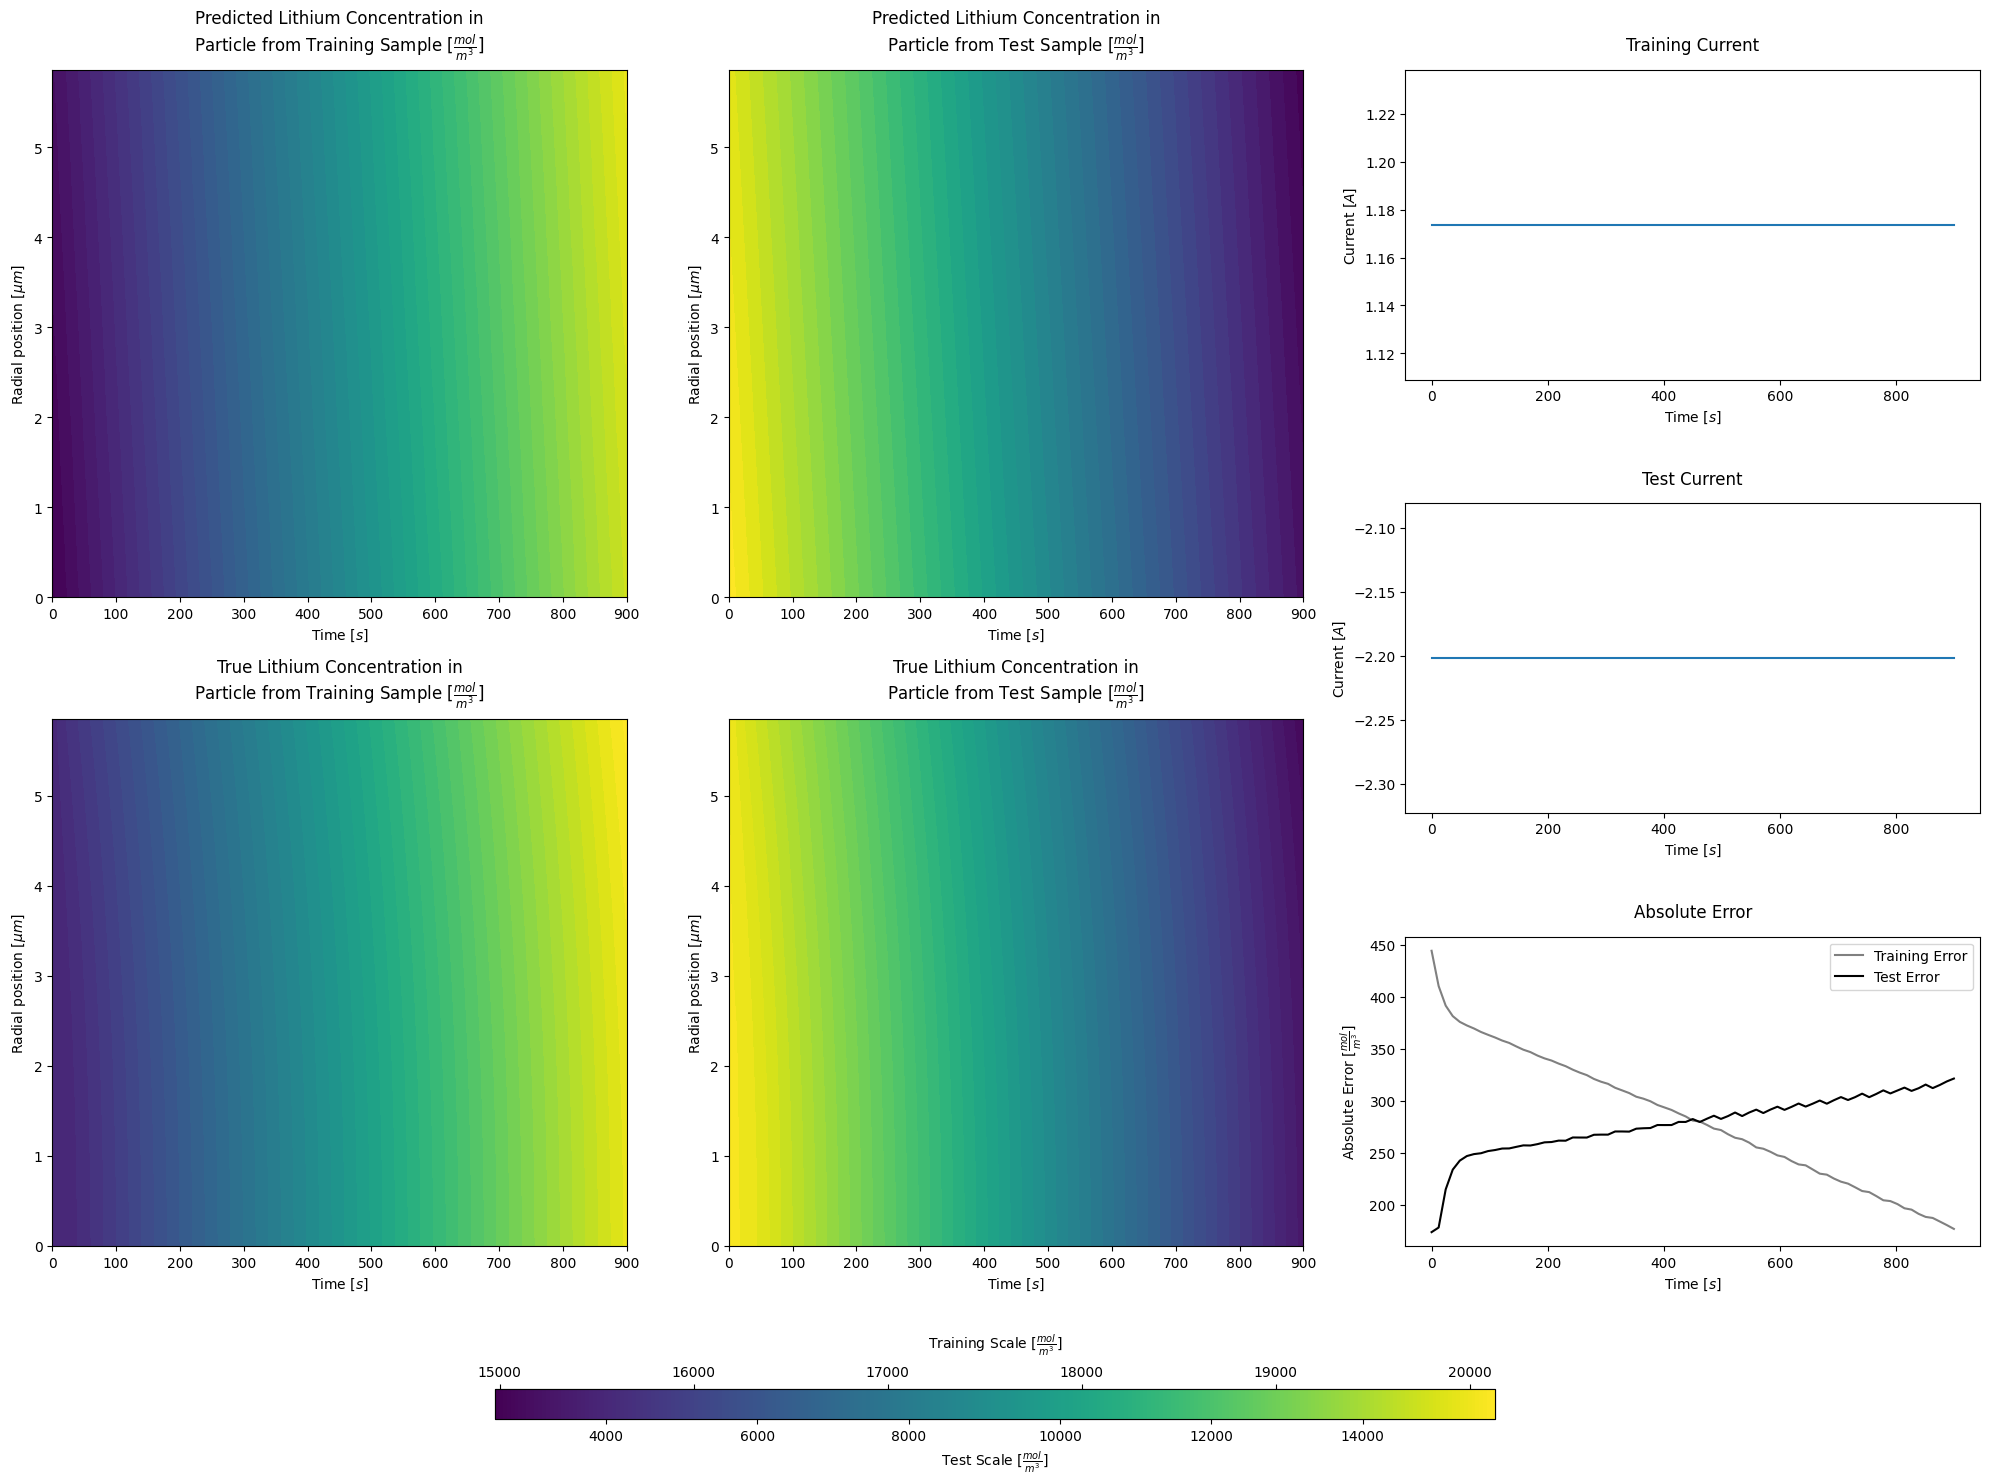

In [23]:
##ANODE

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import jax.numpy as jnp
import numpy as np
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

# Compute error lines
train_error_line_anode = jnp.mean(jnp.abs(c_train_pred_scaled_anode - c_train_true_scaled_anode), axis=0)  # shape (75,)
test_error_line_anode = jnp.mean(jnp.abs(c_test_pred_scaled_anode - c_test_true_scaled_anode), axis=0)      # shape (75,)

#t_plot = np.linspace(0,1800,75)

T_plot, R_plot = jnp.meshgrid(t, r)

# Extract data for anode and cathode
a_data = np.concatenate([
    c_train_pred_scaled_anode.ravel(),
    c_train_true_scaled_anode.ravel()
])
c_data = np.concatenate([
    c_test_pred_scaled_anode.ravel(),
    c_test_true_scaled_anode.ravel()
])

a_min, a_max = a_data.min(), a_data.max()
c_min, c_max = c_data.min(), c_data.max()

# Create separate norms for anode and cathode
a_norm = Normalize(vmin=a_min, vmax=a_max)
c_norm = Normalize(vmin=c_min, vmax=c_max)

# Create the figure and main GridSpec
fig = plt.figure(figsize=(20, 15))
gs = gridspec.GridSpec(2, 3, figure=fig)

def rasterize_contour(contour):
    for c in contour.collections:
        c.set_rasterized(True)

# Anode Plots (use a_norm)
ax1 = fig.add_subplot(gs[0,0])
contour1 = ax1.contourf(T_plot, R_plot*Ran*1e6, c_train_pred_scaled_anode,
                        levels=50, cmap='viridis', norm=a_norm)
#rasterize_contour(contour1)
ax1.set_xlabel('Time [$s$]')
ax1.set_ylabel('Radial position [$µm$]')
ax1.set_title('Predicted Lithium Concentration in\nParticle from Training Sample [$\\frac{mol}{m^3}$]', pad=14)

ax4 = fig.add_subplot(gs[1,0])
contour3 = ax4.contourf(T_plot, R_plot*Ran*1e6, c_train_true_scaled_anode,
                        levels=50, cmap='viridis', norm=a_norm)
#rasterize_contour(contour3)
ax4.set_xlabel('Time [$s$]')
ax4.set_ylabel('Radial position [$µm$]')
ax4.set_title('True Lithium Concentration in\nParticle from Training Sample [$\\frac{mol}{m^3}$]', pad=14)

# Cathode Plots (use c_norm)
ax2 = fig.add_subplot(gs[0,1])
contour2 = ax2.contourf(T_plot, R_plot*Ran*1e6, c_test_pred_scaled_anode,
                        levels=50, cmap='viridis', norm=c_norm)
#rasterize_contour(contour2)
ax2.set_xlabel('Time [$s$]')
ax2.set_ylabel('Radial position [$µm$]')
ax2.set_title('Predicted Lithium Concentration in\nParticle from Test Sample [$\\frac{mol}{m^3}$]', pad=14)

ax5 = fig.add_subplot(gs[1,1])
contour4 = ax5.contourf(T_plot, R_plot*Ran*1e6, c_test_true_scaled_anode,
                        levels=50, cmap='viridis', norm=c_norm)
#rasterize_contour(contour4)
ax5.set_xlabel('Time [$s$]')
ax5.set_ylabel('Radial position [$µm$]')
ax5.set_title('True Lithium Concentration in\nParticle from Test Sample [$\\frac{mol}{m^3}$]', pad=14)

# Right column subdivided into three rows: Current, Voltage, Error
right_gs = gridspec.GridSpecFromSubplotSpec(3, 1, subplot_spec=gs[:, 2], hspace=0.4)

ax_curr = fig.add_subplot(right_gs[0,0])
ax_curr.plot(t, train_I[train_idx])
ax_curr.set_title('Training Current', pad=14)
ax_curr.set_xlabel('Time [$s$]')
ax_curr.set_ylabel('Current [$A$]')

ax_volt = fig.add_subplot(right_gs[1,0])
ax_volt.plot(t, test_I[test_idx], linestyle='-')
#ax_volt.plot(t_plot[:sim_length], V_pred[:sim_length], label='PINN', linestyle='--')
ax_volt.set_title('Test Current', pad=14)
ax_volt.set_xlabel('Time [$s$]')
ax_volt.set_ylabel('Current [$A$]')

ax_err = fig.add_subplot(right_gs[2,0])
ax_err.plot(t, train_error_line_anode, color='grey', label='Training Error', linestyle='-')
ax_err.plot(t, test_error_line_anode, color='black', label='Test Error', linestyle='-')
ax_err.set_title('Absolute Error', pad=14)
ax_err.set_xlabel('Time [$s$]')
ax_err.set_ylabel('Absolute Error [$\\frac{mol}{m^3}$]')
ax_err.legend()

plt.tight_layout(rect=[0,0.125,1,1])  # Leave more space at the bottom for two colorbars

# Create two separate ScalarMappables for the colorbars
sm_anode = ScalarMappable(norm=a_norm, cmap='viridis')
sm_anode.set_array([])
sm_cathode = ScalarMappable(norm=c_norm, cmap='viridis')
sm_cathode.set_array([])

# Add the two colorbars side by side at the bottom
# Adjust positions as needed
cbar_width = 0.5
cbar_height = 0.02
cbar_anode_ax = fig.add_axes([0.25, 0.05, cbar_width, cbar_height])
cbar_cathode_ax = fig.add_axes([0.25, 0.05, cbar_width, cbar_height])

cbar_anode = fig.colorbar(sm_anode, cax=cbar_anode_ax, orientation='horizontal')
cbar_anode.set_label('Training Scale [$\\frac{mol}{m^3}$]', labelpad=12)
cbar_anode.ax.xaxis.set_label_position('top')
cbar_anode.ax.xaxis.set_ticks_position('top')

cbar_cathode = fig.colorbar(sm_cathode, cax=cbar_cathode_ax, orientation='horizontal')
cbar_cathode.set_label('Test Scale [$\\frac{mol}{m^3}$]')

# Save as rasterized SVG with a chosen DPI
fig.savefig("plots/DON/anode/" + str(train_idx) + "_vs_" + str(test_idx) + "_rasterized.svg", format='svg', transparent=True, dpi=300)
plt.show()

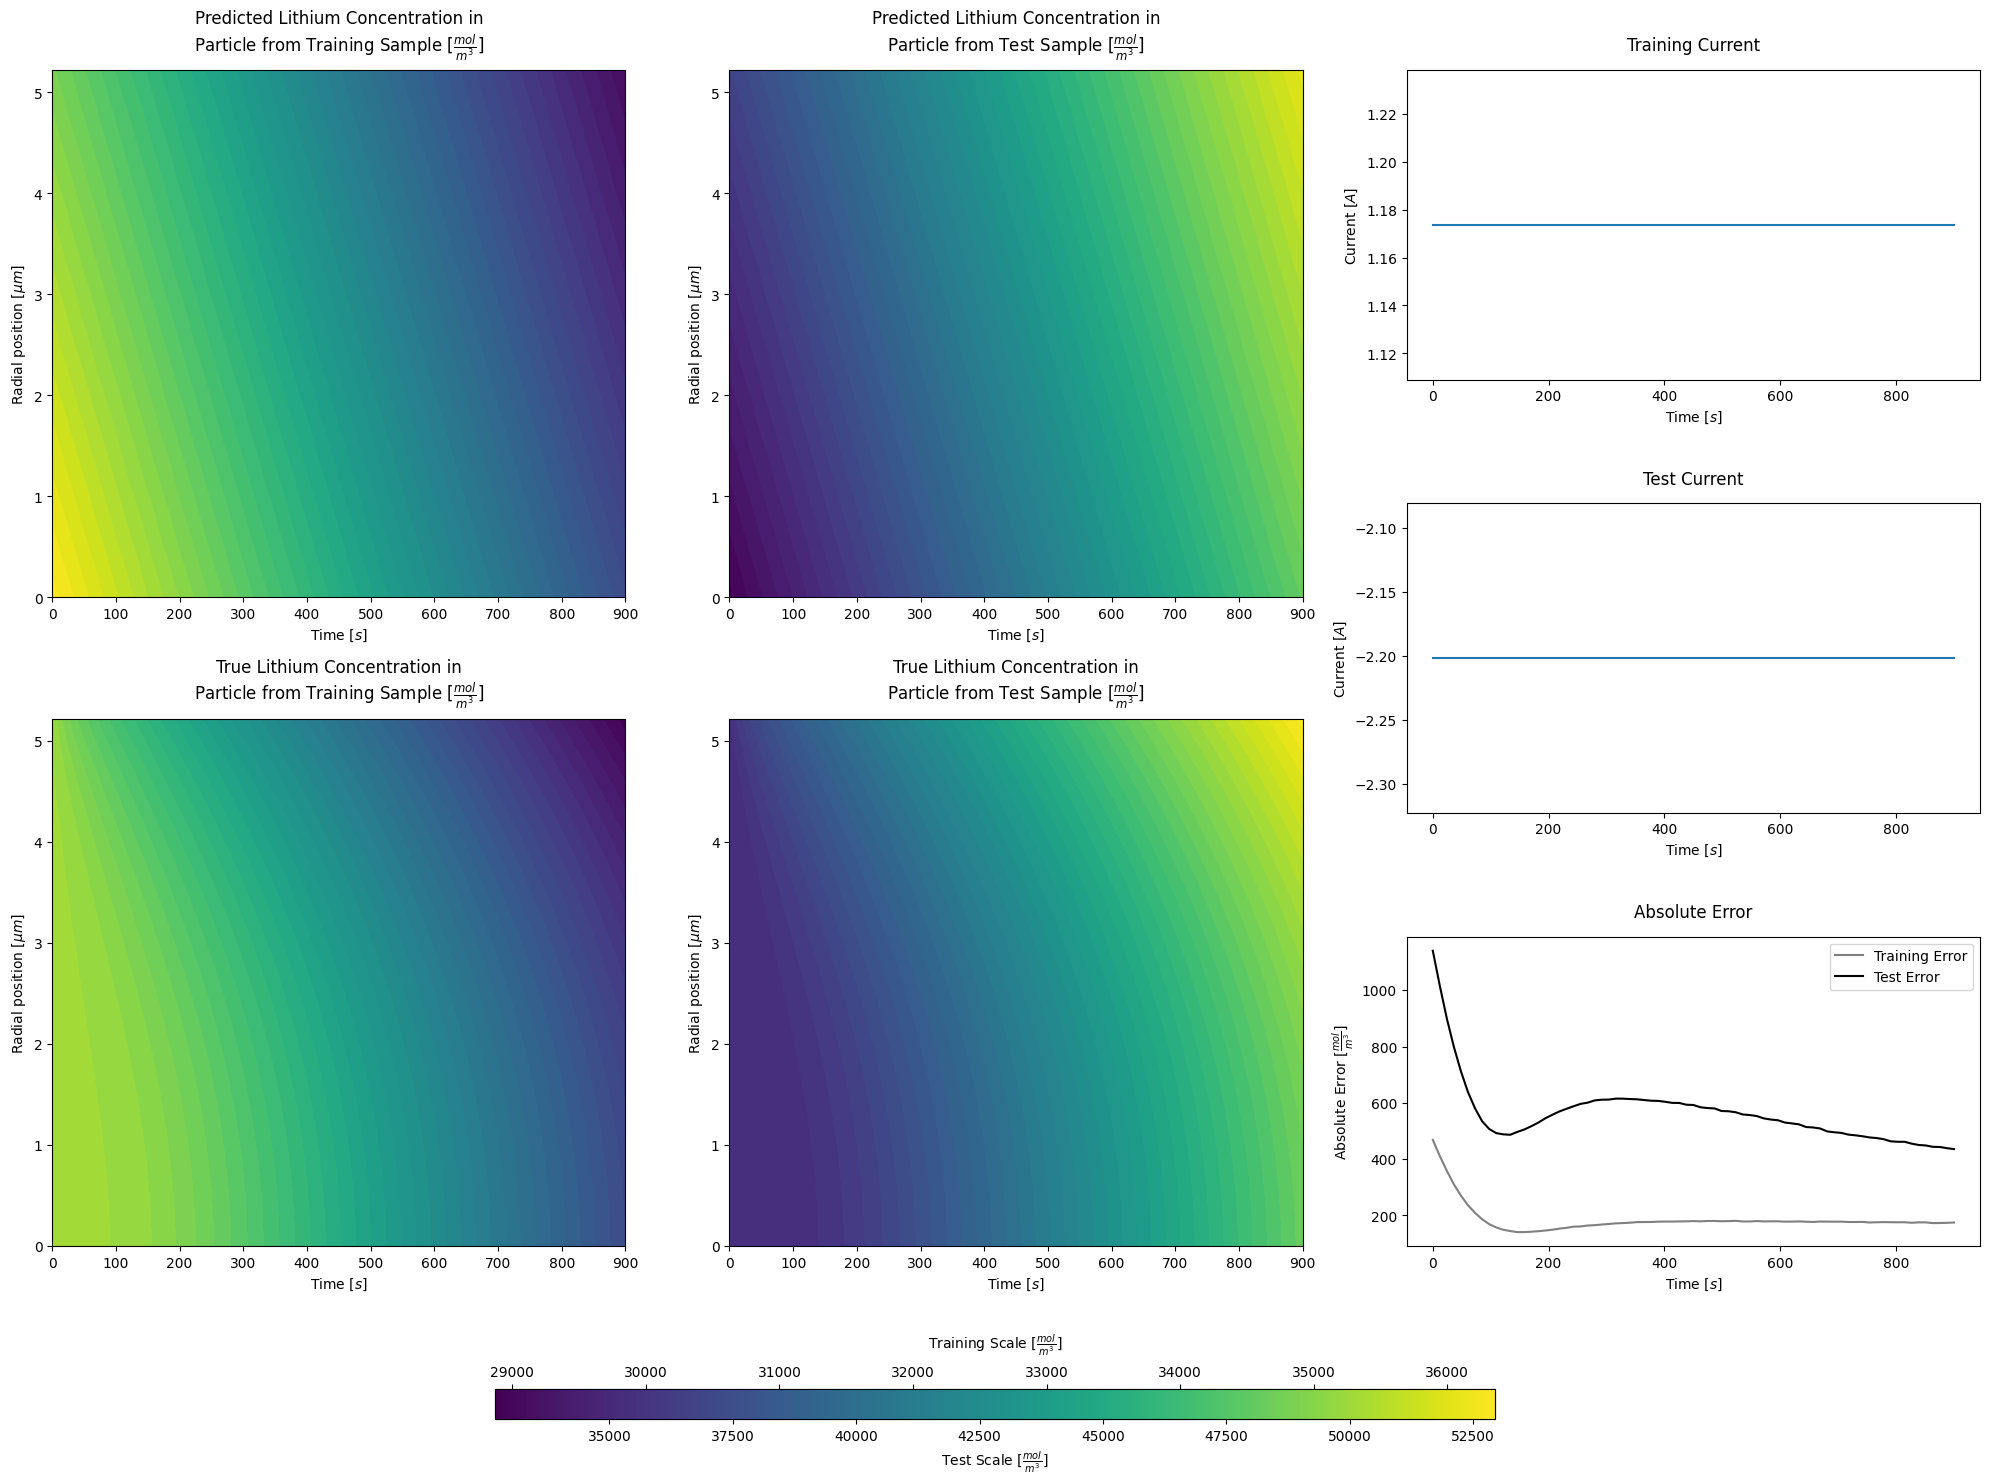

In [24]:
##CATHODE

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import jax.numpy as jnp
import numpy as np
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

# Compute error lines
train_error_line_cathode = jnp.mean(jnp.abs(c_train_pred_scaled_cathode - c_train_true_scaled_cathode), axis=0)  # shape (75,)
test_error_line_cathode = jnp.mean(jnp.abs(c_test_pred_scaled_cathode - c_test_true_scaled_cathode), axis=0)      # shape (75,)

#t_plot = np.linspace(0,1800,75)

T_plot, R_plot = jnp.meshgrid(t, r)

# Extract data for anode and cathode
a_data = np.concatenate([
    c_train_pred_scaled_cathode.ravel(),
    c_train_true_scaled_cathode.ravel()
])
c_data = np.concatenate([
    c_test_pred_scaled_cathode.ravel(),
    c_test_true_scaled_cathode.ravel()
])

a_min, a_max = a_data.min(), a_data.max()
c_min, c_max = c_data.min(), c_data.max()

# Create separate norms for anode and cathode
a_norm = Normalize(vmin=a_min, vmax=a_max)
c_norm = Normalize(vmin=c_min, vmax=c_max)

# Create the figure and main GridSpec
fig = plt.figure(figsize=(20, 15))
gs = gridspec.GridSpec(2, 3, figure=fig)

def rasterize_contour(contour):
    for c in contour.collections:
        c.set_rasterized(True)

# Anode Plots (use a_norm)
ax1 = fig.add_subplot(gs[0,0])
contour1 = ax1.contourf(T_plot, R_plot*Rca*1e6, c_train_pred_scaled_cathode,
                        levels=50, cmap='viridis', norm=a_norm)
#rasterize_contour(contour1)
ax1.set_xlabel('Time [$s$]')
ax1.set_ylabel('Radial position [$µm$]')
ax1.set_title('Predicted Lithium Concentration in\nParticle from Training Sample [$\\frac{mol}{m^3}$]', pad=14)

ax4 = fig.add_subplot(gs[1,0])
contour3 = ax4.contourf(T_plot, R_plot*Rca*1e6, c_train_true_scaled_cathode,
                        levels=50, cmap='viridis', norm=a_norm)
#rasterize_contour(contour3)
ax4.set_xlabel('Time [$s$]')
ax4.set_ylabel('Radial position [$µm$]')
ax4.set_title('True Lithium Concentration in\nParticle from Training Sample [$\\frac{mol}{m^3}$]', pad=14)

# Cathode Plots (use c_norm)
ax2 = fig.add_subplot(gs[0,1])
contour2 = ax2.contourf(T_plot, R_plot*Rca*1e6, c_test_pred_scaled_cathode,
                        levels=50, cmap='viridis', norm=c_norm)
#rasterize_contour(contour2)
ax2.set_xlabel('Time [$s$]')
ax2.set_ylabel('Radial position [$µm$]')
ax2.set_title('Predicted Lithium Concentration in\nParticle from Test Sample [$\\frac{mol}{m^3}$]', pad=14)

ax5 = fig.add_subplot(gs[1,1])
contour4 = ax5.contourf(T_plot, R_plot*Rca*1e6, c_test_true_scaled_cathode,
                        levels=50, cmap='viridis', norm=c_norm)
#rasterize_contour(contour4)
ax5.set_xlabel('Time [$s$]')
ax5.set_ylabel('Radial position [$µm$]')
ax5.set_title('True Lithium Concentration in\nParticle from Test Sample [$\\frac{mol}{m^3}$]', pad=14)

# Right column subdivided into three rows: Current, Voltage, Error
right_gs = gridspec.GridSpecFromSubplotSpec(3, 1, subplot_spec=gs[:, 2], hspace=0.4)

ax_curr = fig.add_subplot(right_gs[0,0])
ax_curr.plot(t, train_I[train_idx])
ax_curr.set_title('Training Current', pad=14)
ax_curr.set_xlabel('Time [$s$]')
ax_curr.set_ylabel('Current [$A$]')

ax_volt = fig.add_subplot(right_gs[1,0])
ax_volt.plot(t, test_I[test_idx], linestyle='-')
#ax_volt.plot(t_plot[:sim_length], V_pred[:sim_length], label='PINN', linestyle='--')
ax_volt.set_title('Test Current', pad=14)
ax_volt.set_xlabel('Time [$s$]')
ax_volt.set_ylabel('Current [$A$]')

ax_err = fig.add_subplot(right_gs[2,0])
ax_err.plot(t, train_error_line_cathode, color='grey', label='Training Error', linestyle='-')
ax_err.plot(t, test_error_line_cathode, color='black', label='Test Error', linestyle='-')
ax_err.set_title('Absolute Error', pad=14)
ax_err.set_xlabel('Time [$s$]')
ax_err.set_ylabel('Absolute Error [$\\frac{mol}{m^3}$]')
ax_err.legend()

plt.tight_layout(rect=[0,0.125,1,1])  # Leave more space at the bottom for two colorbars

# Create two separate ScalarMappables for the colorbars
sm_anode = ScalarMappable(norm=a_norm, cmap='viridis')
sm_anode.set_array([])
sm_cathode = ScalarMappable(norm=c_norm, cmap='viridis')
sm_cathode.set_array([])

# Add the two colorbars side by side at the bottom
# Adjust positions as needed
cbar_width = 0.5
cbar_height = 0.02
cbar_anode_ax = fig.add_axes([0.25, 0.05, cbar_width, cbar_height])
cbar_cathode_ax = fig.add_axes([0.25, 0.05, cbar_width, cbar_height])

cbar_anode = fig.colorbar(sm_anode, cax=cbar_anode_ax, orientation='horizontal')
cbar_anode.set_label('Training Scale [$\\frac{mol}{m^3}$]', labelpad=12)
cbar_anode.ax.xaxis.set_label_position('top')
cbar_anode.ax.xaxis.set_ticks_position('top')

cbar_cathode = fig.colorbar(sm_cathode, cax=cbar_cathode_ax, orientation='horizontal')
cbar_cathode.set_label('Test Scale [$\\frac{mol}{m^3}$]')

# Save as rasterized SVG with a chosen DPI
#fig.savefig("FNO/2DFNOTriangle" + str(train_idx) + "_rasterized.svg", format='svg', transparent=True, dpi=300)
fig.savefig("plots/DON/cathode/" + str(train_idx) + "_vs_" + str(test_idx) + "_rasterized.svg", format='svg', transparent=True, dpi=300)
plt.show()

In [25]:
# Compute V_pred and V_true using post_proc function
#from functions import post_proc
V_pred, V_true = functions.post_proc(params_bat, test_I[test_idx], c_pred_an_surf, c_true_an_surf, c_pred_ca_surf, c_true_ca_surf, Ran, Rca, epsan, epsca, Lan, Lca, A)

In [64]:
plt.rcParams.update({
    'font.size': 42,        # Global font size for most text
    'font.family': 'DejaVu Sans', # Global font family
    'axes.titlesize': 44    # Font size for titles
})


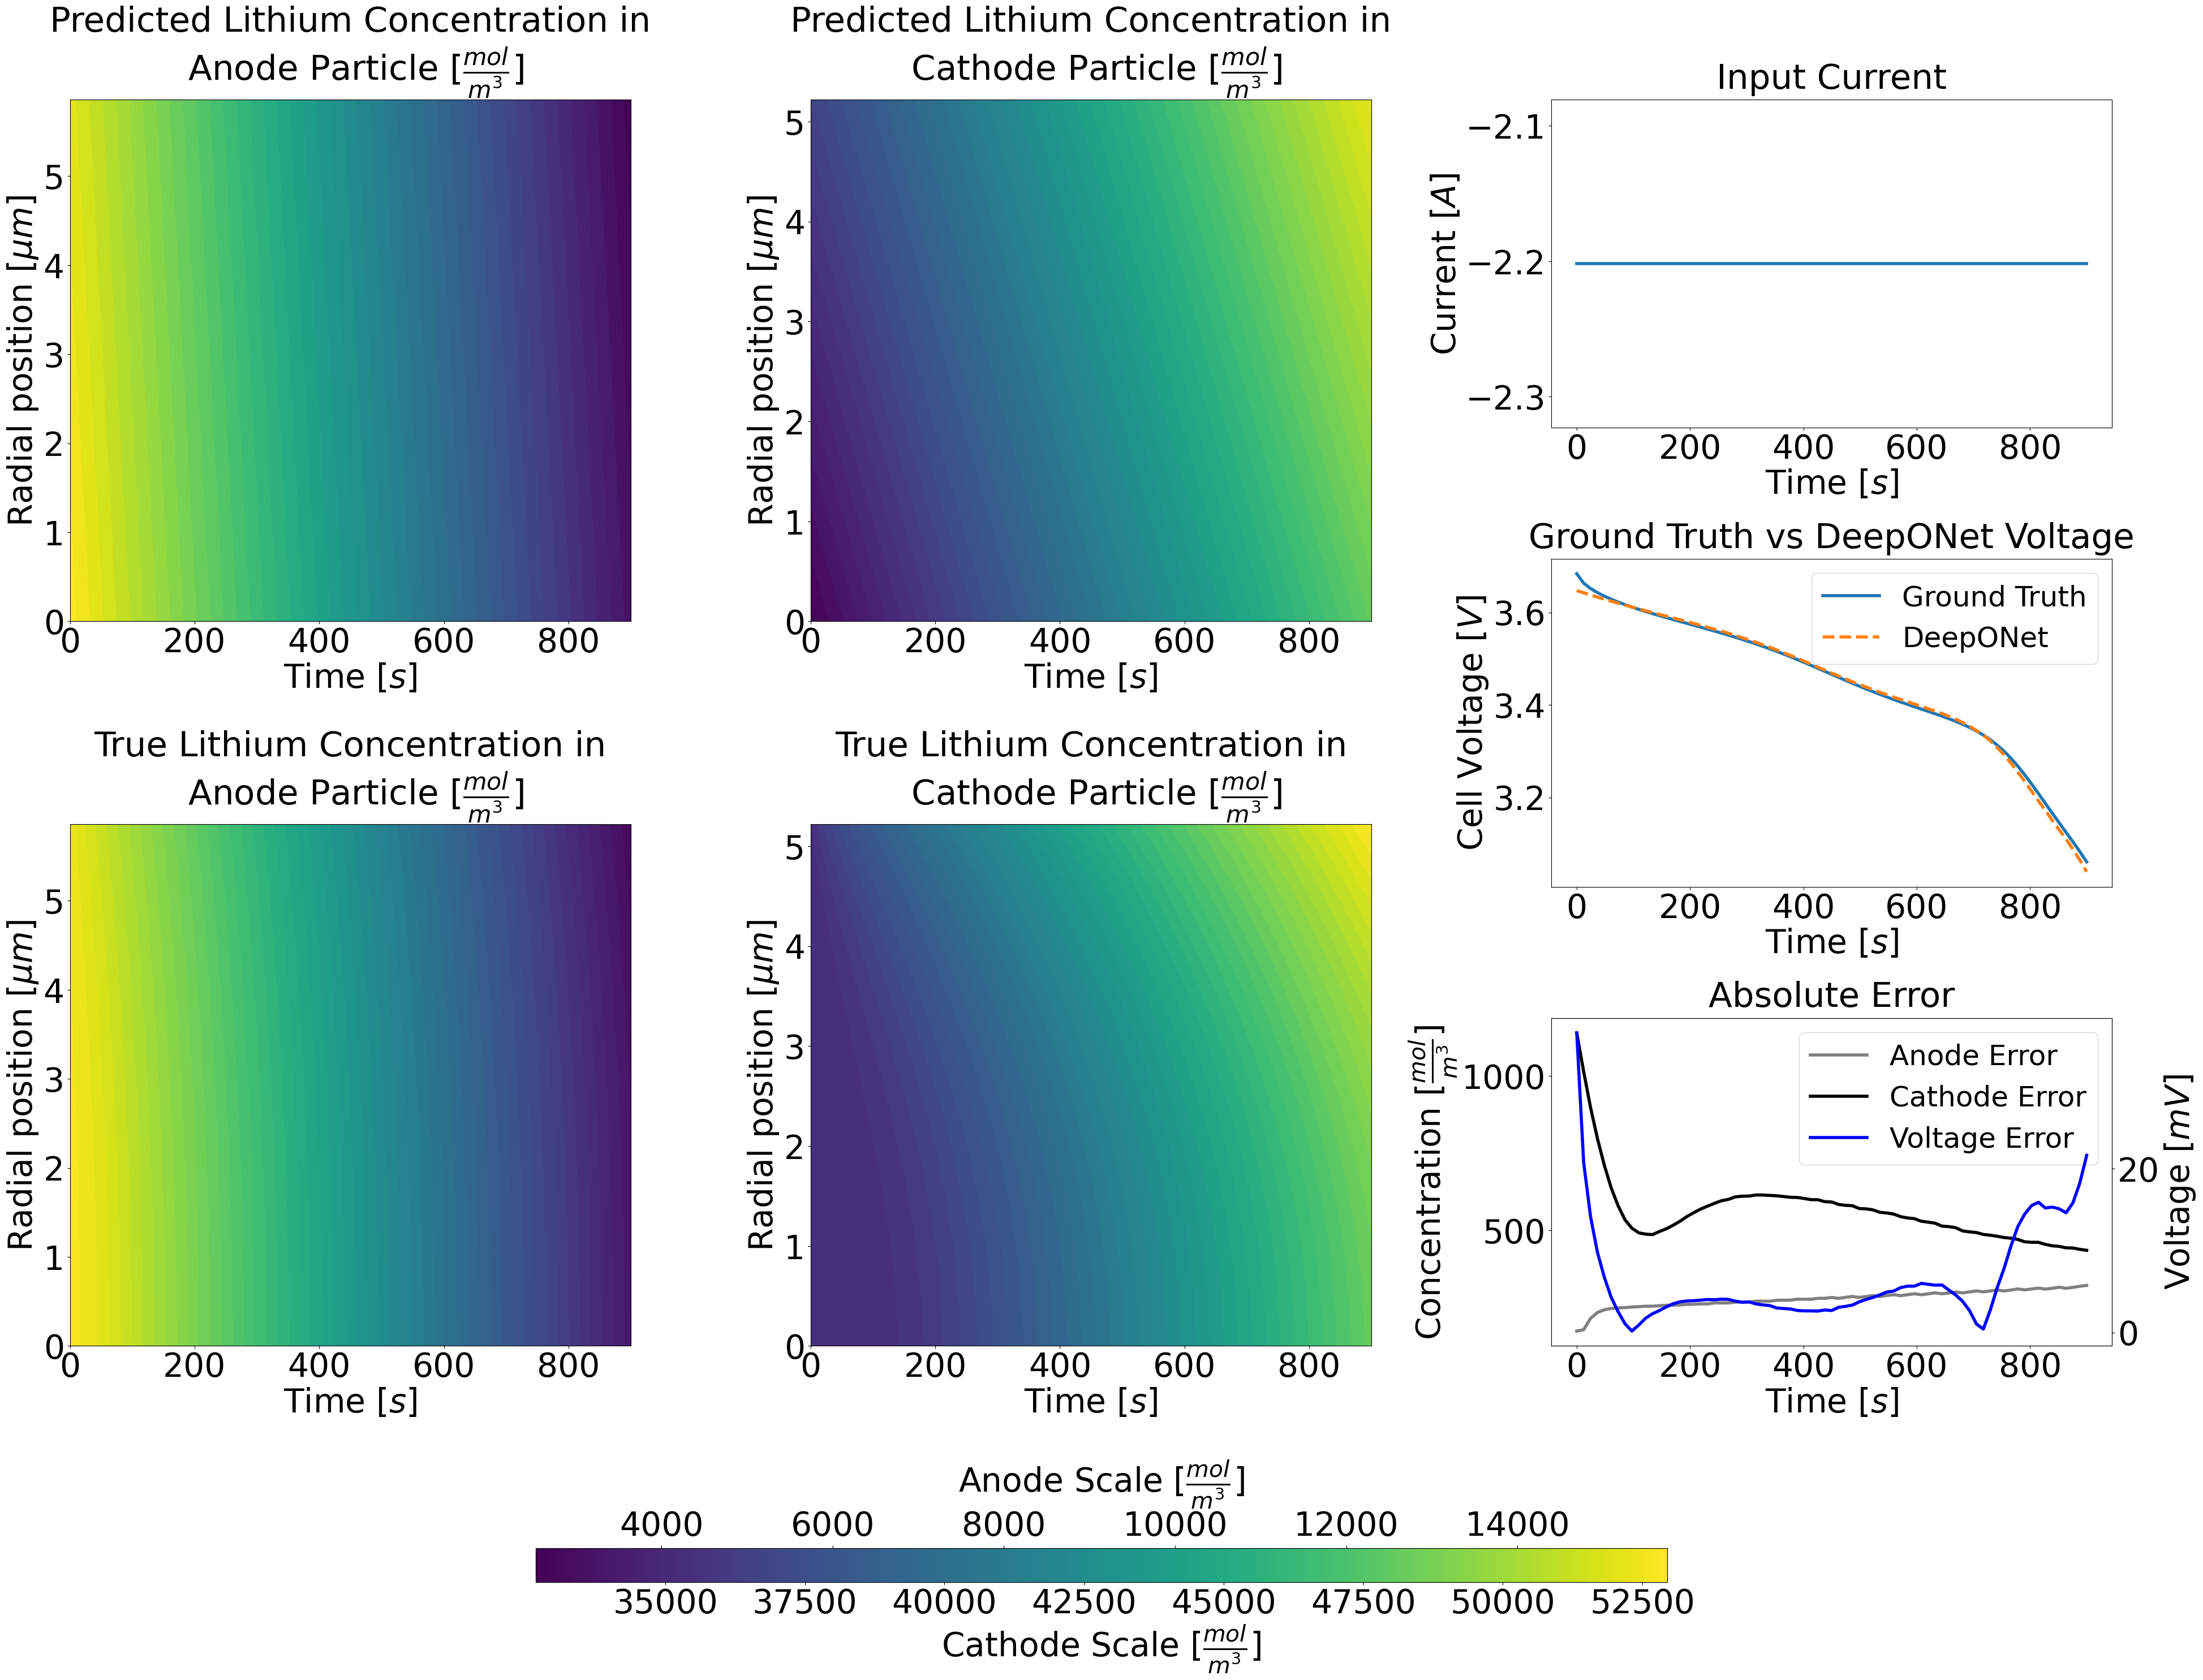

In [65]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import jax.numpy as jnp
import numpy as np
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

# Compute error lines
anode_error_line = jnp.mean(jnp.abs(c_test_pred_scaled_anode - c_test_true_scaled_anode), axis=0)  # shape (75,)
cathode_error_line = jnp.mean(jnp.abs(c_test_pred_scaled_cathode - c_test_true_scaled_cathode), axis=0)      # shape (75,)
diff = jnp.abs(V_pred-V_true)

#t_plot = np.linspace(0,1800,75)

T_plot, R_plot = jnp.meshgrid(t, r)

# Extract data for anode and cathode
a_data = np.concatenate([
    c_test_pred_scaled_anode.ravel(),
    c_test_true_scaled_anode.ravel()
])
c_data = np.concatenate([
    c_test_pred_scaled_cathode.ravel(),
    c_test_true_scaled_cathode.ravel()
])

a_min, a_max = a_data.min(), a_data.max()
c_min, c_max = c_data.min(), c_data.max()

# Create separate norms for anode and cathode
a_norm = Normalize(vmin=a_min, vmax=a_max)
c_norm = Normalize(vmin=c_min, vmax=c_max)

# Create the figure and main GridSpec
fig = plt.figure(figsize=(40, 30))
gs = gridspec.GridSpec(2, 3, figure=fig)

def rasterize_contour(contour):
    for c in contour.collections:
        c.set_rasterized(True)

# Anode Plots (use a_norm)
ax1 = fig.add_subplot(gs[0,0])
contour1 = ax1.contourf(T_plot, R_plot*Ran*1e6, c_test_pred_scaled_anode,
                        levels=50, cmap='viridis', norm=a_norm)
#rasterize_contour(contour1)
ax1.set_xlabel('Time [$s$]')
ax1.set_ylabel('Radial position [$µm$]')
ax1.set_title('Predicted Lithium Concentration in\n Anode Particle [$\\frac{mol}{m^3}$]', pad=14)

ax4 = fig.add_subplot(gs[1,0])
contour3 = ax4.contourf(T_plot, R_plot*Ran*1e6, c_test_true_scaled_anode,
                        levels=50, cmap='viridis', norm=a_norm)
#rasterize_contour(contour3)
ax4.set_xlabel('Time [$s$]')
ax4.set_ylabel('Radial position [$µm$]')
ax4.set_title('True Lithium Concentration in\n Anode Particle [$\\frac{mol}{m^3}$]', pad=14)

# Cathode Plots (use c_norm)
ax2 = fig.add_subplot(gs[0,1])
contour2 = ax2.contourf(T_plot, R_plot*Rca*1e6, c_test_pred_scaled_cathode,
                        levels=50, cmap='viridis', norm=c_norm)
#rasterize_contour(contour2)
ax2.set_xlabel('Time [$s$]')
ax2.set_ylabel('Radial position [$µm$]')
ax2.set_title('Predicted Lithium Concentration in\n Cathode Particle [$\\frac{mol}{m^3}$]', pad=14)

ax5 = fig.add_subplot(gs[1,1])
contour4 = ax5.contourf(T_plot, R_plot*Rca*1e6, c_test_true_scaled_cathode,
                        levels=50, cmap='viridis', norm=c_norm)
#rasterize_contour(contour4)
ax5.set_xlabel('Time [$s$]')
ax5.set_ylabel('Radial position [$µm$]')
ax5.set_title('True Lithium Concentration in\n Cathode Particle [$\\frac{mol}{m^3}$]', pad=14)

# Right column subdivided into three rows: Current, Voltage, Error
right_gs = gridspec.GridSpecFromSubplotSpec(3, 1, subplot_spec=gs[:, 2], hspace=0.4)

ax_curr = fig.add_subplot(right_gs[0,0])
ax_curr.plot(t, test_I[test_idx], linewidth=4)
ax_curr.set_title('Input Current', pad=14)
ax_curr.set_xlabel('Time [$s$]')
ax_curr.set_ylabel('Current [$A$]')

ax_volt = fig.add_subplot(right_gs[1,0])
ax_volt.plot(t, V_true, label='Ground Truth', linestyle='-', linewidth=4)
ax_volt.plot(t, V_pred, label='DeepONet', linestyle='--', linewidth=4)
ax_volt.set_title('Ground Truth vs DeepONet Voltage', pad=14)
ax_volt.set_xlabel('Time [$s$]')
ax_volt.set_ylabel('Cell Voltage [$V$]')
ax_volt.legend(fontsize=36)

ax_err = fig.add_subplot(right_gs[2,0])
line1, = ax_err.plot(t, anode_error_line, color='grey', label='Anode Error', linestyle='-', linewidth=4)
line2, = ax_err.plot(t, cathode_error_line, color='black', label='Cathode Error', linestyle='-', linewidth=4)
ax_err.set_title('Absolute Error', pad=14)
ax_err.set_xlabel('Time [$s$]')
ax_err.set_ylabel('Concentration [$\\frac{mol}{m^3}$]')
#ax_err.legend()

# Create a secondary y-axis for voltage
ax_voltage_err = ax_err.twinx()
line3, = ax_voltage_err.plot(t, diff * 1000, color='blue', label='Voltage Error', linestyle='-', linewidth=4)
ax_voltage_err.set_ylabel('Voltage [$mV$]')
#ax_voltage_err.legend(loc='upper right')

# Combine the legend handles and labels from both axes
lines = [line1, line2, line3]
labels = [line.get_label() for line in lines]
ax_err.legend(lines, labels, loc='upper right',  fontsize=36)#, bbox_to_anchor=(0.5, 1.15), ncol=3)

plt.tight_layout(rect=[0,0.125,1,1])  # Leave more space at the bottom for two colorbars

# Create two separate ScalarMappables for the colorbars
sm_anode = ScalarMappable(norm=a_norm, cmap='viridis')
sm_anode.set_array([])
sm_cathode = ScalarMappable(norm=c_norm, cmap='viridis')
sm_cathode.set_array([])

# Add the two colorbars side by side at the bottom
# Adjust positions as needed
cbar_width = 0.5
cbar_height = 0.02
cbar_anode_ax = fig.add_axes([0.25, 0.05, cbar_width, cbar_height])
cbar_cathode_ax = fig.add_axes([0.25, 0.05, cbar_width, cbar_height])

cbar_anode = fig.colorbar(sm_anode, cax=cbar_anode_ax, orientation='horizontal')
cbar_anode.set_label('Anode Scale [$\\frac{mol}{m^3}$]', labelpad=24)
cbar_anode.ax.xaxis.set_label_position('top')
cbar_anode.ax.xaxis.set_ticks_position('top')

cbar_cathode = fig.colorbar(sm_cathode, cax=cbar_cathode_ax, orientation='horizontal')
cbar_cathode.set_label('Cathode Scale [$\\frac{mol}{m^3}$]')

# Save as rasterized SVG with a chosen DPI
fig.savefig("plots/DON/Voltage_" + str(test_idx) + "_rasterized.svg", format='svg', transparent=True, dpi=600)
plt.show()

In [66]:
test_idx

20

In [67]:
test_c0_anode[test_idx,:]

Array([0.46847972, 0.46847972, 0.46847972, 0.46847972, 0.46847972,
       0.46847972, 0.46847972, 0.46847972, 0.46847972, 0.46847972,
       0.46847972, 0.46847972, 0.46847972, 0.46847972, 0.46847972,
       0.46847972, 0.46847972, 0.46847972, 0.46847972, 0.46847972],      dtype=float32)

In [68]:
import pybamm
import numpy as np

spm = pybamm.lithium_ion.SPM()
spm.events = []
# spm.initial_conditions[spm.variables["X-averaged negative particle concentration"]] = pybamm.Array(np.array(c_train_true_anode[:,0]))
# spm.initial_conditions[spm.variables["X-averaged positive particle concentration"]] = pybamm.Array(np.array(c_train_true_cathode[:,0]))
soc = 0.3

params_bat["Current function [A]"] = pybamm.Interpolant(t, -1.* test_I[test_idx], pybamm.t)

sim = pybamm.Simulation(spm, parameter_values=params_bat)#, solver=fast_solver)
sol = sim.solve(initial_soc=soc, t_eval=t)

sol.plot()

interactive(children=(FloatSlider(value=0.0, description='t', max=900.0, step=9.0), Output()), _dom_classes=('…

In [69]:
c_train_true_anode[:, 0].shape

(2200, 75)

In [70]:
c0_anode = sol["Negative particle concentration"].entries[:,0,0]
cn_target_anode = sol["Negative particle concentration"].entries[:,0,:]

c0_cathode = sol["Positive particle concentration"].entries[:,0,0]
cn_target_cathode = sol["Positive particle concentration"].entries[:,0,:]

In [71]:
np.sum(np.abs(cn_target_anode-test_cn_anode[test_idx]).flatten())

114.50136

In [72]:
np.allclose(test_cn_anode[test_idx].flatten(),cn_target_anode.flatten())

False

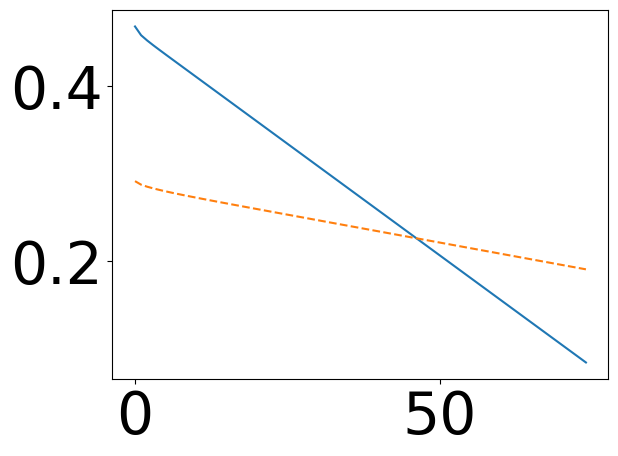

In [73]:
plt.plot(test_cn_anode[test_idx][-1,:])
plt.plot(cn_target_anode[-1,:], "--")

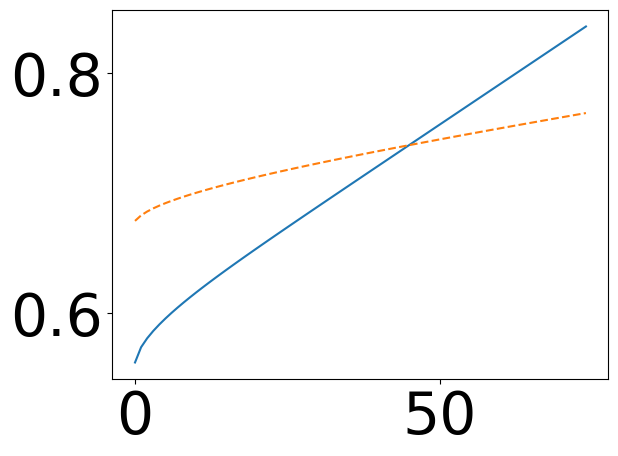

In [74]:
plt.plot(test_cn_cathode[test_idx][-1,:])
plt.plot(cn_target_cathode[-1,:], "--")